<a href="https://colab.research.google.com/github/sans0726/100-days-of-deep-learning/blob/main/GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Sequence of 5 time steps
X = np.array([
    [[0.1],
     [0.2]],

    [[0.2],
     [0.3]],

    [[0.3],
     [0.4]],

    [[0.4],
     [0.5]],

    [[0.5],
     [0.6]]
])

# Initial hidden state
h = np.zeros((2, 1))

hidden_states = []

# Process each time step
for t in range(len(X)):

    x_t = X[t]

    # Update gate
    z_t = sigmoid(
        W_z @ x_t +
        U_z @ h +
        b_z
    )

    # Reset gate
    r_t = sigmoid(
        W_r @ x_t +
        U_r @ h +
        b_r
    )

    # Candidate hidden state
    h_candidate = np.tanh(
        W_h @ x_t +
        U_h @ (r_t * h) +
        b_h
    )

    # New hidden state
    h = (1 - z_t) * h + z_t * h_candidate

    hidden_states.append(h.copy())


print("Number of time steps:", len(hidden_states))

for t, state in enumerate(hidden_states):
    print(f"\nTime step {t + 1}:")
    print(state)

Number of time steps: 5

Time step 1:
[[0.20036318]
 [0.08342417]]

Time step 2:
[[0.38650048]
 [0.2004788 ]]

Time step 3:
[[0.5748499 ]
 [0.31199419]]

Time step 4:
[[0.73129662]
 [0.40907329]]

Time step 5:
[[0.8378547 ]
 [0.49219794]]


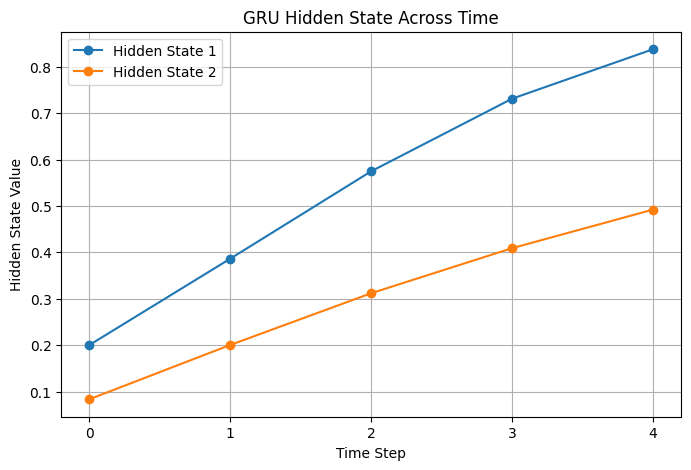

In [3]:
import matplotlib.pyplot as plt

# Convert hidden states into a NumPy array
hidden_array = np.array(hidden_states).squeeze()

# Plot each hidden-state neuron
plt.figure(figsize=(8, 5))

plt.plot(hidden_array[:, 0], marker="o", label="Hidden State 1")
plt.plot(hidden_array[:, 1], marker="o", label="Hidden State 2")

plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.title("GRU Hidden State Across Time")
plt.xticks(range(5))
plt.legend()
plt.grid(True)

plt.show()

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [5]:
model = Sequential([
    GRU(
        units=2,
        input_shape=(5, 2),
        return_sequences=False
    ),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39 (156.00 B)

 Trainable params: 39 (156.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
X_train = np.array([
    [[0.1, 0.2],
     [0.2, 0.3],
     [0.3, 0.4],
     [0.4, 0.5],
     [0.5, 0.6]],

    [[0.2, 0.1],
     [0.3, 0.2],
     [0.4, 0.3],
     [0.5, 0.4],
     [0.6, 0.5]],

    [[0.5, 0.4],
     [0.4, 0.3],
     [0.3, 0.2],
     [0.2, 0.1],
     [0.1, 0.0]],

    [[0.1, 0.3],
     [0.2, 0.4],
     [0.3, 0.5],
     [0.4, 0.6],
     [0.5, 0.7]]
])

y_train = np.array([
    [0.7],
    [0.8],
    [0.2],
    [0.9]
])

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (4, 5, 2)
y shape: (4, 1)


In [7]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

print("Model compiled successfully.")

Model compiled successfully.
